# Some issues, strange places, and suggestions in `TensorFlow`'s official document "Basic training loops"

I've learnt a lot of `TensorFlow` from the official documentation. I appreciate the official documents helping me solve many problems in my project. Based on this guide, I also wrote my note on the [Example Problem for Machine Learning 01 - Simple Linear Regression](https://github.com/HsienChing/ML_DL_project_State_Estimation_of_Li-ion_Batteries/blob/main/example_problems/ML_Example_01.ipynb)

There are some issues and strange places when I am reading the official document "[Basic training loops](https://www.tensorflow.org/guide/basic_training_loops)".

This is a brief issue report. I wish we could make the document better and benefit readers / researchers / engineers.

This time, I won't report on many minor issues, such as webpage display and layout problems.

Date: 2026-04-19

## 1. Issues, strange places, and suggestions

### 1.1. Incorrect description in "Define a loss function" subsection

**Position:**  
"Define a loss function" subsection

**Link:**  
https://www.tensorflow.org/guide/basic_training_loops#define_a_loss_function

**Condition:**  
The description said that "Before training the model, you can visualize the loss value by plotting the model's predictions in red and the training data in blue:".

However, the model's prediction is in green instead of red.

**Suggestion:**  
Modify the color description to the correct "green".

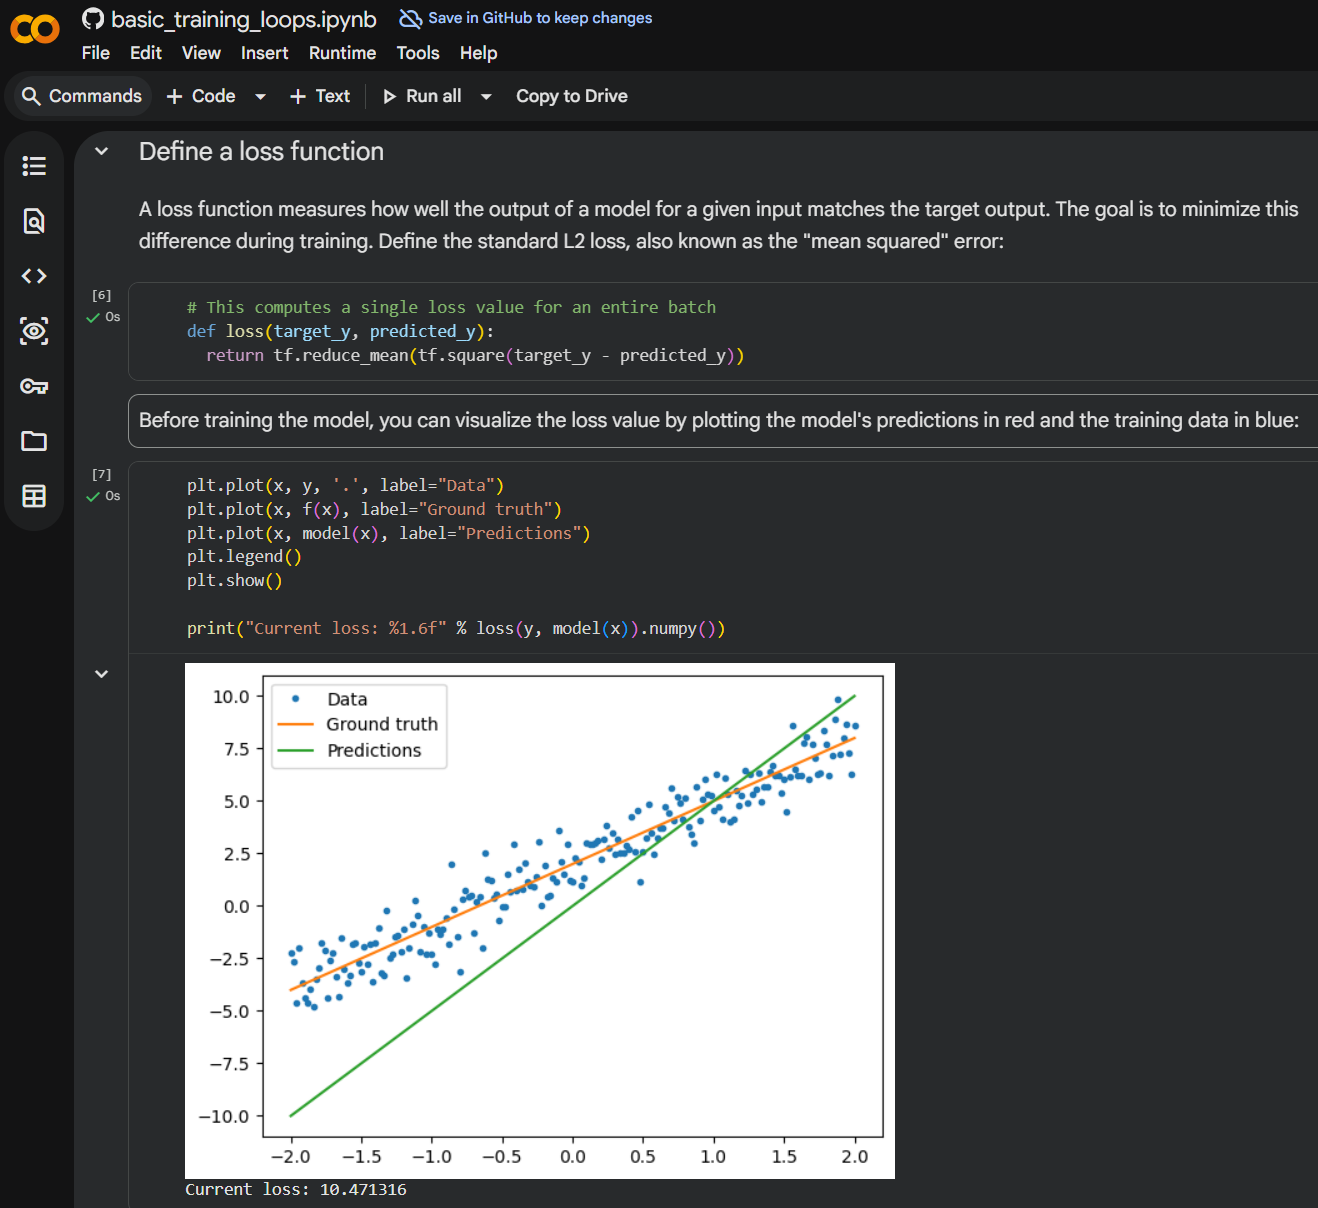  
Screenshot date: 2026-04-19  
Link: [Run in Google Colab](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/guide/basic_training_loops.ipynb)

### 1.2. Better example code of "Define a training loop" subsection

**Position:**  
"Define a training loop" subsection

**Link:**  
https://www.tensorflow.org/guide/basic_training_loops#define_a_training_loop

**Condition:**  
We know that the code [`tape.gradient(y, x)`](https://www.tensorflow.org/api_docs/python/tf/GradientTape) indicates `dy/dx = tape.gradient(y, x)`. 
It's better to write `dy_dx = tape.gradient(y, x)` for beginners, avoiding misleading the theoretial meaning of [gradient descent](https://www.google.com/url?q=https%3A%2F%2Fen.wikipedia.org%2Fwiki%2FGradient_descent).

However, in the guide, the code is provided in the following from
```python
    # Use GradientTape to calculate the gradients with respect to W and b
    dw, db = t.gradient(current_loss, [model.w, model.b])

    # Subtract the gradient scaled by the learning rate
    model.w.assign_sub(learning_rate * dw)
    model.b.assign_sub(learning_rate * db)
```

**Suggestion:**  
A better example is suggested as follows. `dw` and `db` become `dl_dw` and `dl_db`, respectively.
```python
    # Use GradientTape to calculate the gradients with respect to W and b
    dl_dw, dl_db = t.gradient(current_loss, [model.w, model.b])

    # Subtract the gradient scaled by the learning rate
    model.w.assign_sub(learning_rate * dl_dw)
    model.b.assign_sub(learning_rate * dl_db)
```

### 1.3. Bugs in "The same solution, but with Keras" section

**Position:**  
"The same solution, but with Keras" section

**Link:**  
https://www.tensorflow.org/guide/basic_training_loops#the_same_solution_but_with_keras

**Condition:**  
As we run the example code in the [Run in Google Colab](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/guide/basic_training_loops.ipynb), error messages occur.

**Error 1:**
Error message
```python
ValueError: The filename must end in `.weights.h5`. Received: filepath=my_checkpoint
```
from the code
```python
# You can also save a checkpoint using Keras's built-in support
keras_model.save_weights("my_checkpoint")
```

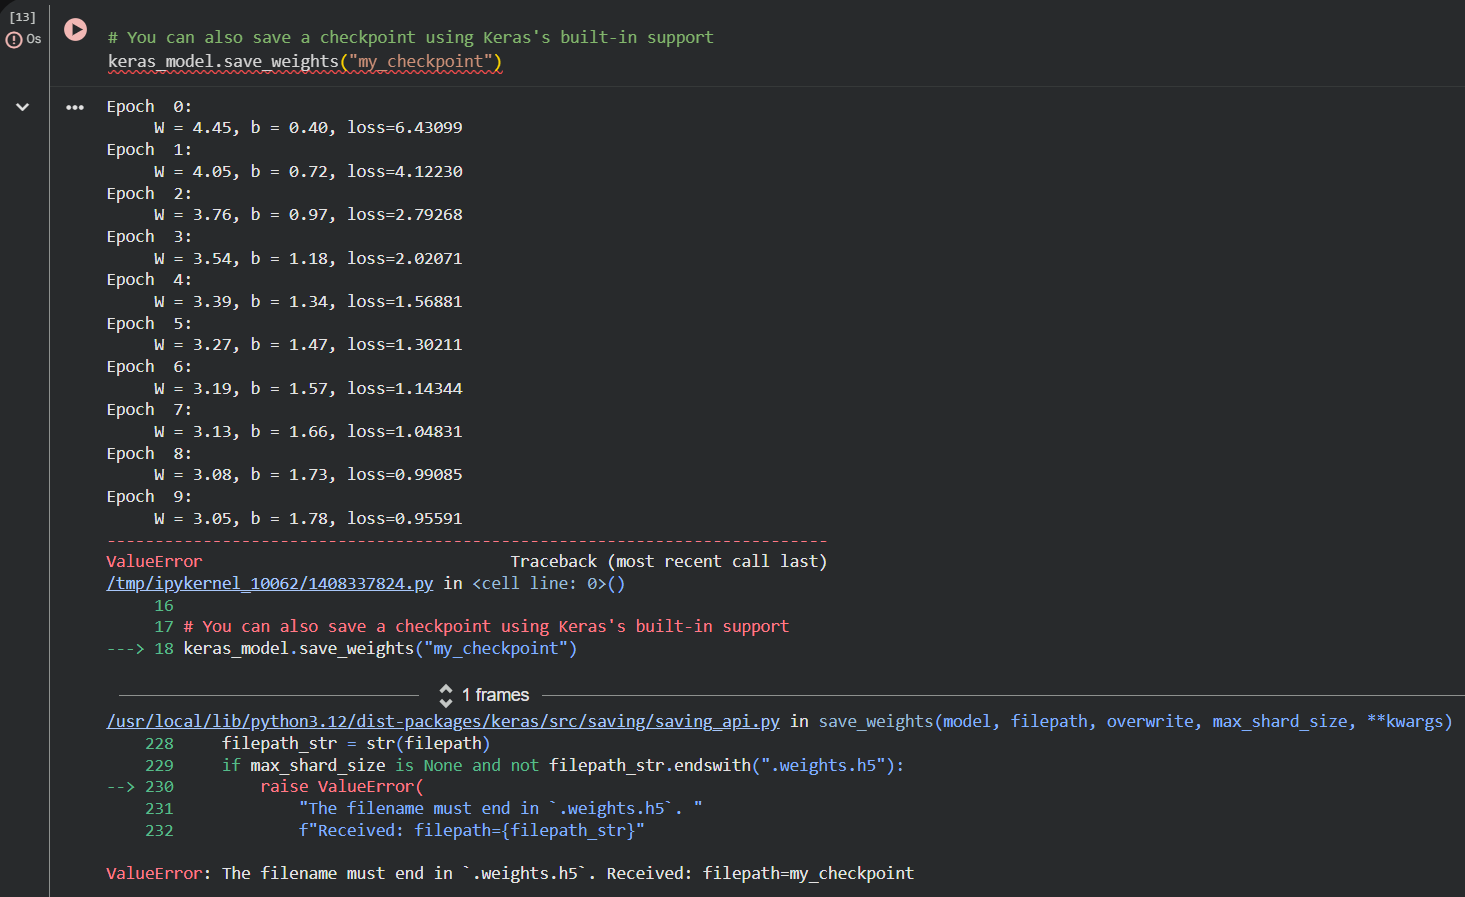  
Screenshot date: 2026-04-19  
Link: [Run in Google Colab](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/guide/basic_training_loops.ipynb)


**Error 2:**  
Error message
```python
AttributeError: module 'keras._tf_keras.keras.losses' has no attribute 'mean_squared_error'
```
from the code
```python
    # Keras comes with built-in MSE error
    # However, you could use the loss function
    # defined above
    loss=tf.keras.losses.mean_squared_error,
)
```

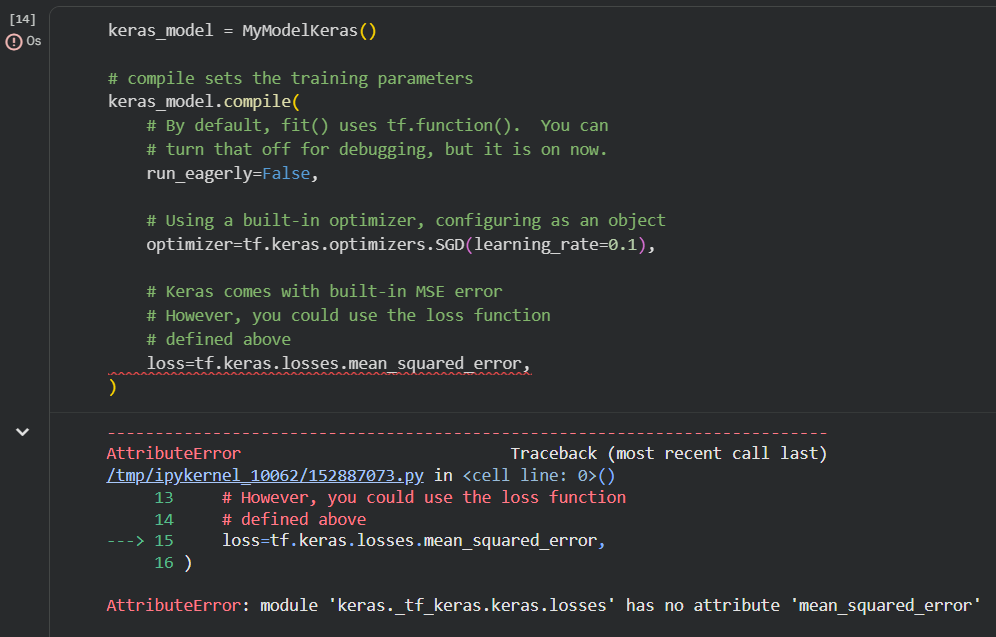  
Screenshot date: 2026-04-19  
Link: [Run in Google Colab](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/guide/basic_training_loops.ipynb)


**Deal with:**  
Report the issue to `TensorFlow`:  
https://github.com/tensorflow/tensorflow/issues/116299

My Gist:  N/A